# Coffee Shop Member Retention Analysis

## Summary
This analysis looks at what drives customer retention among members of a coffee shop loyalty program. Using 2 years of transaction data (July 2023 - June 2025) from 2.2 million members, I explored which factors predict whether a member will return within 45 days of their first purchase. I also investigated whether there is a retention inflection point - how many visits until a member becomes consistently loyal.

## Approach
1. Combined and cleaned 24 months of transaction data
2. Created a member-level analysis dataset with demographics and first-purchase behavior
3. Defined retention as returning within 45 days of first purchase
4. Used Lasso logistic regression to identify which features best predict retention

## Key Findings
- 70% of members make a second visit at some point
- 43% return within 45 days
- Using a voucher on first visit is the strongest predictor of return
- Members 61+ are significantly less likely to return
- Gender and first purchase amount have no effect on retention

- No retention inflection point exists - members have a consistent ~70% chance of returning regardless of how many previous visits they've made.

## Evaluation Metrics
- Model accuracy: ~51% (limited predictive power with available features)
- Used cross-validation with 5 stratified folds to validate results


#### Note 
This analysis was done as a Capstone Project for the Data Science Short Course through General Assembly (Oct 2025-Jan 2026)

#### Import Data and Combine Multiple Files
The data comes from Kaggle (synthetically generated): https://www.kaggle.com/datasets/geraldooizx/g-coffee-shop-transaction-202307-to-202506

It includes 24 monthly transaction files totaling 14.6 million transactions from a coffee shop in Malaysia.

In [1]:
import pandas as pd
import glob

In [2]:
#Find all transactions data 
all_transactions = glob.glob('./Data/transactions_*.csv')

In [3]:
print(len(all_transactions))

24


In [4]:
#load in all files
transactions_list = []
for file in all_transactions:
    df = pd.read_csv(file)
    transactions_list.append(df)
    print(f"Loaded {file}: {len(df):,} rows")


Loaded ./Data/transactions_202506.csv: 599,566 rows
Loaded ./Data/transactions_202504.csv: 600,686 rows
Loaded ./Data/transactions_202505.csv: 619,942 rows
Loaded ./Data/transactions_202307.csv: 620,262 rows
Loaded ./Data/transactions_202501.csv: 620,337 rows
Loaded ./Data/transactions_202312.csv: 620,777 rows
Loaded ./Data/transactions_202310.csv: 619,396 rows
Loaded ./Data/transactions_202502.csv: 560,492 rows
Loaded ./Data/transactions_202503.csv: 620,171 rows
Loaded ./Data/transactions_202311.csv: 600,545 rows
Loaded ./Data/transactions_202404.csv: 599,847 rows
Loaded ./Data/transactions_202410.csv: 619,693 rows
Loaded ./Data/transactions_202411.csv: 599,869 rows
Loaded ./Data/transactions_202405.csv: 620,230 rows
Loaded ./Data/transactions_202407.csv: 619,618 rows
Loaded ./Data/transactions_202406.csv: 600,448 rows
Loaded ./Data/transactions_202412.csv: 620,342 rows
Loaded ./Data/transactions_202402.csv: 580,012 rows
Loaded ./Data/transactions_202403.csv: 620,481 rows
Loaded ./Dat

In [5]:
# join them together 
transactions = pd.concat(transactions_list, ignore_index=True)

In [6]:
#display in normal number format 
pd.set_option('display.float_format', lambda x: '%.2f' % x)

In [7]:
transactions.head()

,transaction_id,store_id,payment_method_id,voucher_id,user_id,original_amount,discount_applied,final_amount,created_at
0,cf97cf60-a84d-4072-9569-8fa2aaa1584f,10,3,NaN,2020374.00,20.00,0.00,20.00,2025-06-01 12:24:10
1,f827c197-bbfa-472b-952d-9909080f2056,1,1,NaN,2018692.00,68.00,0.00,68.00,2025-06-01 10:24:57
2,b9d95774-3d3f-4050-a13f-451a695419a0,8,3,NaN,1749642.00,63.00,0.00,63.00,2025-06-01 10:24:58
3,c93ed407-6af5-4816-a4d4-4be5626f23b7,10,3,NaN,691127.00,43.00,0.00,43.00,2025-06-01 10:25:00
4,78d9b721-67c7-426b-a963-ae25c9e3b4a5,5,1,NaN,412641.00,48.00,0.00,48.00,2025-06-01 10:25:03


In [8]:
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14623691 entries, 0 to 14623690
Data columns (total 9 columns):
 #   Column             Dtype  
---  ------             -----  
 0   transaction_id     object 
 1   store_id           int64  
 2   payment_method_id  int64  
 3   voucher_id         float64
 4   user_id            float64
 5   original_amount    float64
 6   discount_applied   float64
 7   final_amount       float64
 8   created_at         object 
dtypes: float64(5), int64(2), object(2)
memory usage: 1004.1+ MB


In [9]:
transactions.sample(5)

,transaction_id,store_id,payment_method_id,voucher_id,user_id,original_amount,discount_applied,final_amount,created_at
7115211,f3a9e51e-5ae1-46d6-bf8a-9c533eab9e9a,2,3,NaN,NaN,42.00,0.00,42.00,2024-10-23 11:59:48
11300422,898722f2-3b59-432e-a211-5187384a4783,5,3,NaN,15161.00,9.50,0.00,9.50,2024-03-19 13:54:50
8744388,07048437-831e-4ae1-985f-ea13c2b231c5,7,2,NaN,34290.00,27.00,0.00,27.00,2024-07-13 11:02:32
7327341,995e75e6-a852-45ec-9d07-d747ca6f75c8,3,2,NaN,154114.00,54.00,0.00,54.00,2024-11-03 11:29:35
207312,9de98234-c2f0-4488-b81b-25dfb63050ef,4,4,NaN,987370.00,57.00,0.00,57.00,2025-06-11 14:45:33


In [10]:
# number of transactions for members vs. non-members
member_count = transactions['user_id'].notna().sum()
non_member_count = transactions['user_id'].isna().sum()

print(member_count)
print(non_member_count)

7312864
7310827


In [11]:
# find all users files 
all_users = glob.glob('./Data/users_*.csv')

In [12]:
print(len(all_users))

24


In [13]:
# load in all users files 
user_list = []
for u_file in all_users:
    df = pd.read_csv(u_file)
    user_list.append(df)
    print(f"Loaded {u_file}: {len(df):,} rows")

Loaded ./Data/users_202409.csv: 140,626 rows
Loaded ./Data/users_202408.csv: 127,455 rows
Loaded ./Data/users_202309.csv: 1,601 rows
Loaded ./Data/users_202308.csv: 938 rows
Loaded ./Data/users_202503.csv: 182,902 rows
Loaded ./Data/users_202311.csv: 4,340 rows
Loaded ./Data/users_202310.csv: 2,655 rows
Loaded ./Data/users_202502.csv: 164,648 rows
Loaded ./Data/users_202312.csv: 7,109 rows
Loaded ./Data/users_202307.csv: 580 rows
Loaded ./Data/users_202501.csv: 179,536 rows
Loaded ./Data/users_202505.csv: 184,015 rows
Loaded ./Data/users_202504.csv: 178,617 rows
Loaded ./Data/users_202506.csv: 178,713 rows
Loaded ./Data/users_202401.csv: 11,576 rows
Loaded ./Data/users_202403.csv: 28,320 rows
Loaded ./Data/users_202402.csv: 17,099 rows
Loaded ./Data/users_202412.csv: 175,867 rows
Loaded ./Data/users_202406.csv: 79,595 rows
Loaded ./Data/users_202407.csv: 106,081 rows
Loaded ./Data/users_202405.csv: 60,458 rows
Loaded ./Data/users_202411.csv: 163,271 rows
Loaded ./Data/users_202410.csv:

In [14]:
# join them together 
users = pd.concat(user_list, ignore_index=True)

In [15]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2196257 entries, 0 to 2196256
Data columns (total 4 columns):
 #   Column         Dtype 
---  ------         ----- 
 0   user_id        int64 
 1   gender         object
 2   birthdate      object
 3   registered_at  object
dtypes: int64(1), object(3)
memory usage: 67.0+ MB


In [16]:
users.sample(10)

,user_id,gender,birthdate,registered_at
1741229,333605,male,1991-04-13,2024-07-24 13:42:13
456584,9451,male,1997-10-14,2023-11-27 11:10:32
725593,1224269,female,1999-08-15,2025-01-17 14:10:14
1370382,53960,male,1972-03-29,2024-03-11 09:57:50
1351453,2196208,female,1990-05-19,2025-06-30 18:23:19
816429,1839862,male,1965-03-23,2025-05-02 08:56:31
218587,441885,male,1972-05-17,2024-08-21 10:26:35
507404,1357422,male,1969-10-30,2025-02-09 12:44:11
2180971,103534,female,1969-01-29,2024-04-23 14:17:20
1984966,944771,female,1997-07-03,2024-11-29 13:50:16


In [17]:
# make gender a boolean 
users['is_female'] = users.gender=='female'

In [18]:
users.describe()

,user_id
count,2196257.00
mean,1098129.00
std,634004.93
min,1.00
25%,549065.00
50%,1098129.00
75%,1647193.00
max,2196257.00


In [19]:
users.sample(5)

,user_id,gender,birthdate,registered_at,is_female
1395619,33388,male,2006-06-27,2024-02-10 07:55:39,False
2075058,712091,female,1996-01-29,2024-10-17 11:50:53,True
1330606,2175524,female,2007-05-31,2025-06-27 12:38:51,True
729415,1228091,female,1981-01-17,2025-01-18 12:02:13,True
2156951,78258,male,1973-04-03,2024-04-04 13:07:39,False


In [20]:
#make sure we don't have duplicate users
all_users = users.drop_duplicates(subset='user_id', keep = 'first')

print(f"Rows after combining: {len(users):,}")
print(f"Rows after deduping: {len(all_users):,}")

# no duplicate users in the separate files!

Rows after combining: 2,196,257
Rows after deduping: 2,196,257


In [21]:
# load all voucher file
vouchers = pd.read_csv('./Data/vouchers.csv')

In [22]:
vouchers.head()

,voucher_id,voucher_code,discount_type,discount_value,valid_from,valid_to
0,1,SALES77,percentage,7.00,2023-07-07,2023-07-09
1,2,SALES88,percentage,8.00,2023-08-08,2023-08-10
2,3,SALES99,percentage,9.00,2023-09-09,2023-09-11
3,4,SALES10,percentage,10.00,2023-10-10,2023-10-12
4,5,SALES11,percentage,11.00,2023-11-11,2023-11-13


In [23]:
# load all store file
stores = pd.read_csv('./Data/stores.csv')

In [24]:
stores.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   store_id     10 non-null     int64  
 1   store_name   10 non-null     object 
 2   street       10 non-null     object 
 3   postal_code  10 non-null     int64  
 4   city         10 non-null     object 
 5   state        10 non-null     object 
 6   latitude     10 non-null     float64
 7   longitude    10 non-null     float64
dtypes: float64(2), int64(2), object(4)
memory usage: 772.0+ bytes


# Exploratory Data Analysis
* dig into the data to see how I might need to play with the features to build a model to understand retention 

In [25]:
users.describe()

,user_id
count,2196257.00
mean,1098129.00
std,634004.93
min,1.00
25%,549065.00
50%,1098129.00
75%,1647193.00
max,2196257.00


In [26]:
transactions.describe()

,store_id,payment_method_id,voucher_id,user_id,original_amount,discount_applied,final_amount
count,14623691.00,14623691.00,617551.00,7312864.00,14623691.00,14623691.00,14623691.00
mean,5.50,3.00,7.91,714031.92,33.24,0.16,33.09
std,2.87,1.41,4.35,590122.31,17.06,1.07,17.02
min,1.00,1.00,1.00,1.00,6.00,0.00,1.00
25%,3.00,2.00,4.00,206788.00,19.00,0.00,19.00
50%,6.00,3.00,8.00,562156.00,31.00,0.00,31.00
75%,8.00,4.00,12.00,1119509.00,45.50,0.00,45.00
max,10.00,5.00,16.00,2196257.00,90.00,45.00,90.00


In [27]:
users.is_female.value_counts()

is_female
False    1098802
True     1097455
Name: count, dtype: int64

In [28]:
#total transactions
len(transactions)

14623691

In [29]:
#total revenue from all stores
transactions.final_amount.sum()

np.float64(483845394.44000006)

In [30]:
# convert created_at to datetime
transactions['created_at'] = pd.to_datetime(transactions.created_at)

### Splitting Members vs. Non-Members
Splitting transactions into member and non-member groups. This analysis focuses only on members.

In [31]:
#filtering transactions to only members 
member_transactions = transactions[transactions.user_id.notna()]

In [32]:
member_transactions.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7312864 entries, 0 to 14623667
Data columns (total 9 columns):
 #   Column             Dtype         
---  ------             -----         
 0   transaction_id     object        
 1   store_id           int64         
 2   payment_method_id  int64         
 3   voucher_id         float64       
 4   user_id            float64       
 5   original_amount    float64       
 6   discount_applied   float64       
 7   final_amount       float64       
 8   created_at         datetime64[ns]
dtypes: datetime64[ns](1), float64(5), int64(2), object(1)
memory usage: 557.9+ MB


In [33]:
member_transactions.describe()

,store_id,payment_method_id,voucher_id,user_id,original_amount,discount_applied,final_amount,created_at
count,7312864.00,7312864.00,266644.00,7312864.00,7312864.00,7312864.00,7312864.00,7312864
mean,5.50,3.00,11.40,714031.92,33.24,0.14,33.10,2024-12-13 13:58:45.826884608
min,1.00,1.00,1.00,1.00,6.00,0.00,1.00,2023-07-01 08:13:07
25%,3.00,2.00,9.00,206788.00,19.00,0.00,19.00,2024-09-14 11:28:53.500000
50%,6.00,3.00,11.00,562156.00,31.00,0.00,31.00,2024-12-26 15:33:03.500000
75%,8.00,4.00,13.00,1119509.00,45.50,0.00,45.00,2025-03-30 13:39:39.500000
max,10.00,5.00,16.00,2196257.00,90.00,45.00,90.00,2025-06-30 19:59:39
std,2.87,1.41,2.67,590122.31,17.05,1.11,17.03,NaN


Consider merging members and stores together for analysis...

In [34]:
member_store_transactions = member_transactions.merge(stores, how = 'inner', on ='store_id')

In [35]:
member_store_transactions.describe()

,store_id,payment_method_id,voucher_id,user_id,original_amount,discount_applied,final_amount,created_at,postal_code,latitude,longitude
count,7312864.00,7312864.00,266644.00,7312864.00,7312864.00,7312864.00,7312864.00,7312864,7312864.00,7312864.00,7312864.00
mean,5.50,3.00,11.40,714031.92,33.24,0.14,33.10,2024-12-13 13:58:45.826884608,61957.63,3.10,101.66
min,1.00,1.00,1.00,1.00,6.00,0.00,1.00,2023-07-01 08:13:07,50998.00,2.91,101.52
25%,3.00,2.00,9.00,206788.00,19.00,0.00,19.00,2024-09-14 11:28:53.500000,62094.00,2.95,101.60
50%,6.00,3.00,11.00,562156.00,31.00,0.00,31.00,2024-12-26 15:33:03.500000,62941.00,2.96,101.70
75%,8.00,4.00,13.00,1119509.00,45.50,0.00,45.00,2025-03-30 13:39:39.500000,63826.00,3.22,101.70
max,10.00,5.00,16.00,2196257.00,90.00,45.00,90.00,2025-06-30 19:59:39,67102.00,3.50,101.78
std,2.87,1.41,2.67,590122.31,17.05,1.11,17.03,NaN,4208.53,0.18,0.07


In [36]:
member_store_transactions.sample(5)

,transaction_id,store_id,payment_method_id,voucher_id,user_id,original_amount,discount_applied,final_amount,created_at,store_name,street,postal_code,city,state,latitude,longitude
1692605,df012770-202d-465e-8363-0a99e00f9b2e,2,5,NaN,783842.00,37.00,0.00,37.00,2025-05-26 15:12:18,G Coffee @ Kondominium Putra,Jln Yew 6X,63826,Kondominium Putra,Selangor Darul Ehsan,2.96,101.52
5869071,e05982d1-a874-4192-bbb1-a3b491baad04,1,5,NaN,531840.00,24.00,0.00,24.00,2024-12-14 09:02:19,G Coffee @ USJ 89q,Jalan Dewan Bahasa 5/9,50998,USJ 89q,Kuala Lumpur,3.12,101.62
3938368,4d78f6d8-b038-48bf-a42b-79f2b0a3362e,5,3,NaN,315037.00,27.00,0.00,27.00,2024-10-13 11:37:44,G Coffee @ Seksyen 21,Jalan Anson 4k,62595,Seksyen 21,Putrajaya,2.94,101.70
1508830,dab2b138-9b49-452c-85cf-9579d1f9659e,9,4,NaN,1658158.00,50.50,0.00,50.50,2025-05-18 10:08:17,G Coffee @ PJS8,Jalan 7/3o,62418,PJS8,Putrajaya,2.95,101.70
3697501,8c893b25-b122-466a-9dcd-788d7718eaf5,3,2,NaN,102247.00,9.50,0.00,9.50,2024-04-22 15:09:04,G Coffee @ USJ 57W,Jalan Bukit Petaling 5/16C,62094,USJ 57W,Putrajaya,2.95,101.66


In [37]:
member_store_transactions.store_name.unique()

array(['G Coffee @ Taman Damansara', 'G Coffee @ USJ 89q',
       'G Coffee @ Bandar Seri Mulia', 'G Coffee @ Seksyen 21',
       'G Coffee @ USJ 57W', 'G Coffee @ Alam Tun Hussein Onn',
       'G Coffee @ Kampung Changkat', 'G Coffee @ PJS8',
       'G Coffee @ Kondominium Putra', 'G Coffee @ Damansara Saujana'],
      dtype=object)

In [40]:
#take a sample of member transactions to keep exploring 
member_transactions_sample = member_transactions.sample(frac = 0.1, random_state = 50)

In [41]:
member_transactions_sample.info()

<class 'pandas.core.frame.DataFrame'>
Index: 731286 entries, 5307546 to 7046474
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   transaction_id     731286 non-null  object        
 1   store_id           731286 non-null  int64         
 2   payment_method_id  731286 non-null  int64         
 3   voucher_id         26714 non-null   float64       
 4   user_id            731286 non-null  float64       
 5   original_amount    731286 non-null  float64       
 6   discount_applied   731286 non-null  float64       
 7   final_amount       731286 non-null  float64       
 8   created_at         731286 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(5), int64(2), object(1)
memory usage: 55.8+ MB


In [42]:
member_transactions_sample.groupby('store_id').final_amount.mean()

store_id
1    33.12
2    33.16
3    33.12
4    33.12
5    32.93
6    33.18
7    33.05
8    33.10
9    33.03
10   33.04
Name: final_amount, dtype: float64

In [43]:
member_transactions_sample.groupby('store_id').final_amount.sum()


store_id
1    2406603.35
2    2428291.89
3    2421164.48
4    2431984.17
5    2410605.39
6    2438134.12
7    2415245.25
8    2424541.06
9    2408387.74
10   2410609.77
Name: final_amount, dtype: float64


* Seems like transactions are pretty consistent across all the stores



In [44]:
# Seeing if discounts differ across stores
member_transactions_sample.groupby('store_id').discount_applied.sum()

store_id
1    10132.66
2    10199.61
3    10688.51
4    10839.33
5    10618.61
6    10377.39
7    10821.25
8    10584.94
9    10259.76
10   10822.23
Name: discount_applied, dtype: float64

In [45]:
#total money (Malaysian MYR) spent

member_transactions.final_amount.sum()
# 242,053,934

np.float64(242053934.32000005)

In [46]:
# seeing if there is variation in the number of transactions across members

member_transactions.user_id.value_counts()



user_id
2.00          40
5.00          40
29.00         38
779.00        37
31.00         37
              ..
1914459.00     1
1914460.00     1
1914462.00     1
1914463.00     1
614139.00      1
Name: count, Length: 2196257, dtype: int64

**Results show that members are coming back! Some members seem 'loyal' but need to see how often they come back to the coffee shops.**

In [47]:
#similar patterns on transactions by store for just members 
member_transactions.groupby('store_id').user_id.count() 

store_id
1     729747
2     730989
3     730762
4     733068
5     731695
6     731553
7     731328
8     731648
9     730541
10    731533
Name: user_id, dtype: int64

In [48]:
# look into non_member transactions
non_member_transactions = transactions[transactions.user_id.isna()]

In [49]:
non_member_transactions.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7310827 entries, 39 to 14623690
Data columns (total 9 columns):
 #   Column             Dtype         
---  ------             -----         
 0   transaction_id     object        
 1   store_id           int64         
 2   payment_method_id  int64         
 3   voucher_id         float64       
 4   user_id            float64       
 5   original_amount    float64       
 6   discount_applied   float64       
 7   final_amount       float64       
 8   created_at         datetime64[ns]
dtypes: datetime64[ns](1), float64(5), int64(2), object(1)
memory usage: 557.8+ MB


In [50]:
member_transactions.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7312864 entries, 0 to 14623667
Data columns (total 9 columns):
 #   Column             Dtype         
---  ------             -----         
 0   transaction_id     object        
 1   store_id           int64         
 2   payment_method_id  int64         
 3   voucher_id         float64       
 4   user_id            float64       
 5   original_amount    float64       
 6   discount_applied   float64       
 7   final_amount       float64       
 8   created_at         datetime64[ns]
dtypes: datetime64[ns](1), float64(5), int64(2), object(1)
memory usage: 557.9+ MB


In [51]:
member_transactions.final_amount.sum()

np.float64(242053934.32000005)

In [52]:
non_member_transactions.final_amount.sum()

np.float64(241791460.11999992)

* members and non-members have similar spending patterns 

In [53]:
import matplotlib.pyplot as plt

In [54]:
member_transactions.groupby('store_id').final_amount.sum()

store_id
1    24141158.68
2    24217704.77
3    24192789.77
4    24252460.95
5    24207507.48
6    24199824.73
7    24175105.31
8    24238764.86
9    24211200.09
10   24217417.68
Name: final_amount, dtype: float64

In [55]:
non_member_transactions.groupby('store_id').final_amount.sum()

store_id
1    24192551.62
2    24150464.62
3    24191655.67
4    24150681.70
5    24228596.09
6    24182817.34
7    24161435.04
8    24197399.06
9    24128797.82
10   24207061.16
Name: final_amount, dtype: float64

In [56]:
# calculate age of users when they registered
# first convert fields to datetime 
users['birthdate'] = pd.to_datetime(users.birthdate)
users['registered_at'] = pd.to_datetime(users.registered_at)

In [57]:
users['user_age'] = (users.registered_at - users.birthdate).dt.days / 365.25

In [58]:
users.sample()

,user_id,gender,birthdate,registered_at,is_female,user_age
909550,1932983,female,1978-03-11,2025-05-17 14:19:27,True,47.18


In [59]:
# average age of all users 
users.user_age.mean()

np.float64(37.90218339295458)

In [60]:
# see how many of which voucher was used across member transactions. 
member_transactions.voucher_id.value_counts(dropna=False)

voucher_id
NaN      7046220
15.00      41795
12.00      38106
11.00      35670
10.00      32253
13.00      31066
9.00       27891
8.00       22694
7.00       17134
16.00      13879
14.00       3790
5.00         935
4.00         522
3.00         320
6.00         255
2.00         196
1.00         138
Name: count, dtype: int64

In [61]:
# seems like more vouchers were used by non-members. 
print(non_member_transactions.voucher_id.notna().sum())
print(member_transactions.voucher_id.notna().sum())

350907
266644


### Calculating Days Between Visits
Sorting transactions by user and date to calculate how many days pass between first and second visit.

In [62]:

member_transactions_sorted = member_transactions.sort_values(['user_id', 'created_at']).reset_index(drop=True)

member_transactions_sorted['visit_number'] = member_transactions_sorted.groupby('user_id').cumcount() + 1

# filter to just first and second visits
first_visits = member_transactions_sorted[member_transactions_sorted['visit_number'] == 1][['user_id', 'created_at']]
first_visits.columns = ['user_id', 'first_visit_date']

second_visits = member_transactions_sorted[member_transactions_sorted['visit_number'] == 2][['user_id', 'created_at']]
second_visits.columns = ['user_id', 'second_visit_date']

# Merge 
visit_dates = first_visits.merge(second_visits, on='user_id', how='left')

# Calculate days diff
visit_dates['days_diff'] = (visit_dates['second_visit_date'] - visit_dates['first_visit_date']).dt.days


In [63]:
member_transactions_sorted.head()

,transaction_id,store_id,payment_method_id,voucher_id,user_id,original_amount,discount_applied,final_amount,created_at,visit_number
0,3d30749d-c07b-4d61-8ce7-d85038024b2a,7,2,NaN,1.00,14.00,0.00,14.00,2023-07-01 08:13:07,1
1,5ca24fa9-4f33-499e-8666-55fc378f6fc8,4,2,NaN,1.00,36.50,0.00,36.50,2023-07-01 09:11:53,2
2,53409fb5-9f65-40ae-9cca-1d6096fa3d6f,1,2,NaN,1.00,16.00,0.00,16.00,2023-07-01 09:35:10,3
3,278ef677-36e5-492b-b3e2-f4f9e6362ca6,4,5,NaN,1.00,31.00,0.00,31.00,2023-07-01 12:17:31,4
4,fbebb30e-79d0-4246-8bbf-4dd788aaa3cd,6,5,NaN,1.00,7.00,0.00,7.00,2023-07-01 12:19:05,5


In [64]:
visit_dates.sample(10)

,user_id,first_visit_date,second_visit_date,days_diff
252971,252972.00,2024-06-30 11:10:02,2024-07-09 13:50:05,9.00
1348961,1348962.00,2025-02-08 09:23:18,2025-06-15 15:56:30,127.00
452773,452774.00,2024-08-23 14:17:02,2024-10-05 10:28:00,42.00
466247,466248.00,2024-08-26 15:45:10,2024-09-18 13:09:20,22.00
1808675,1808676.00,2025-04-26 15:07:03,NaT,NaN
946559,946560.00,2024-11-30 07:34:21,NaT,NaN
262366,262367.00,2024-07-03 11:44:32,2024-07-05 13:45:03,2.00
1399819,1399820.00,2025-02-16 14:15:37,NaT,NaN
726035,726036.00,2024-10-20 09:00:32,2024-11-07 15:12:22,18.00
2138594,2138595.00,2025-06-21 11:18:07,NaT,NaN


In [65]:
#number of members who made at least one purchase
total_members_w_purchase = len(visit_dates)

In [66]:
# Days to Second Visit

# what do visits look like? 
print(f"Total members: {len(visit_dates)}")
print(f"Members who made a 2nd purchase: {visit_dates['days_diff'].notna().sum()}")
print(f"Members who never returned: {visit_dates['days_diff'].isna().sum()}")

Total members: 2196257
Members who made a 2nd purchase: 1536904
Members who never returned: 659353


In [67]:
# Distribution of days to second visit (for those who returned)
days_diff_valid = visit_dates['days_diff'].dropna()

print(f"\nDays to second visit - Summary Stats:")
print(days_diff_valid.describe())


Days to second visit - Summary Stats:
count   1536904.00
mean         48.18
std          48.06
min           0.00
25%          13.00
50%          33.00
75%          68.00
max         466.00
Name: days_diff, dtype: float64


### Member Retention Overview


In [68]:
# using mean of to determine threshold of 45 days for retention definition
users_within_45 = (visit_dates.days_diff <= 45).sum()

In [69]:
retention_rate = (users_within_45 / total_members_w_purchase)*100

In [70]:
print(f"Retention rate: {retention_rate:.1f}%")

Retention rate: 42.8%


In [71]:
print(f"Total members: {total_members_w_purchase}")
print(f"Users who returned within 45 days: {users_within_45}")
print(f"Users with ANY second visit: {visit_dates['days_diff'].notna().sum()}")

Total members: 2196257
Users who returned within 45 days: 939573
Users with ANY second visit: 1536904


In [72]:
print(f"Total members: {total_members_w_purchase} (100%)")
print(f"Made a 2nd visit (ever): {visit_dates['days_diff'].notna().sum()} ({visit_dates['days_diff'].notna().sum()/total_members_w_purchase*100:.1f}%)")
print(f"Made a 2nd visit within 45 days: {users_within_45} ({users_within_45/total_members_w_purchase*100:.1f}%)")

Total members: 2196257 (100%)
Made a 2nd visit (ever): 1536904 (70.0%)
Made a 2nd visit within 45 days: 939573 (42.8%)


* Most members are coming back a second time, but only half come within 45 days. 

### Building Member Analysis Dataset
Combining demographics with features from first visit for the predictive model

In [73]:
first_purchase_amount = member_transactions_sorted[member_transactions_sorted['visit_number']==1][['user_id'
                                                                                                   ,'final_amount', 'store_id'
                                                                                                   , 'payment_method_id', 'voucher_id']].rename(columns={'final_amount': 'first_purchase_amount'})



In [74]:
first_purchase_amount.describe()

# 31 is the median 

,user_id,first_purchase_amount,store_id,payment_method_id,voucher_id
count,2196257.00,2196257.00,2196257.00,2196257.00,79976.00
mean,1098129.00,33.10,5.50,3.00,11.41
std,634004.93,17.02,2.87,1.41,2.67
min,1.00,1.00,1.00,1.00,1.00
25%,549065.00,19.00,3.00,2.00,9.00
50%,1098129.00,31.00,5.00,3.00,11.00
75%,1647193.00,45.00,8.00,4.00,13.00
max,2196257.00,90.00,10.00,5.00,16.00


In [75]:
first_purchase_amount.head()

,user_id,first_purchase_amount,store_id,payment_method_id,voucher_id
0,1.00,14.00,7,2,NaN
34,2.00,48.00,7,3,NaN
74,3.00,20.00,9,1,NaN
107,4.00,38.00,2,5,NaN
132,5.00,52.00,4,2,NaN


In [76]:
user_spending = member_transactions.groupby('user_id')

In [77]:
total_spent = user_spending.final_amount.sum()

In [78]:
num_transactions = user_spending.transaction_id.count()

In [79]:
#put it together in a new DF
member_spending = pd.DataFrame({
    'total_spent': total_spent,
    'num_transactions': num_transactions
})

In [80]:
member_spending

,total_spent,num_transactions
user_id,,
1.00,1140.47,34
2.00,1256.49,40
3.00,1198.57,33
4.00,831.00,25
5.00,1367.20,40
...,...,...
2196253.00,44.00,1
2196254.00,30.00,1
2196255.00,22.00,1


In [81]:
# merge member_spending with user data
member_analysis = users[['user_id','user_age','is_female']].merge(
    member_spending, on='user_id', how='inner'
)

In [82]:
member_analysis

,user_id,user_age,is_female,total_spent,num_transactions
0,491097,54.54,False,105.50,4
1,488642,52.62,True,96.00,3
2,488643,43.70,True,58.50,1
3,488644,47.78,False,119.00,3
4,488645,30.35,False,84.00,3
...,...,...,...,...,...
2196252,80380,56.70,False,483.00,12
2196253,80381,41.03,True,457.00,14
2196254,80382,32.67,True,137.50,6
2196255,80383,58.86,False,512.50,11


In [83]:
unique_members_returned_45 = pd.DataFrame({
    'user_id': member_transactions['user_id'].unique()
})

In [84]:
returned_45_list = visit_dates[visit_dates['days_diff'] <= 45].index
unique_members_returned_45['returned_45days'] = unique_members_returned_45['user_id'].isin(returned_45_list)

In [85]:
unique_members_returned_45.columns

Index(['user_id', 'returned_45days'], dtype='object')

In [86]:
unique_members_returned_45

,user_id,returned_45days
0,2020374.00,False
1,2018692.00,False
2,1749642.00,False
3,691127.00,True
4,412641.00,True
...,...,...
2196252,495552.00,False
2196253,495567.00,True
2196254,495602.00,True
2196255,495678.00,True


In [87]:
member_analysis = member_analysis.merge(
    unique_members_returned_45,
    on='user_id',
    how='left'
)

In [88]:
member_analysis.head()

,user_id,user_age,is_female,total_spent,num_transactions,returned_45days
0,491097,54.54,False,105.50,4,False
1,488642,52.62,True,96.00,3,False
2,488643,43.70,True,58.50,1,False
3,488644,47.78,False,119.00,3,False
4,488645,30.35,False,84.00,3,False


In [89]:
member_analysis.user_age.min()

14.146475017111568

#### Building some visualizations 
* to see any possible additional trends

Text(0.5, 1.0, 'Member Spending Distribution')

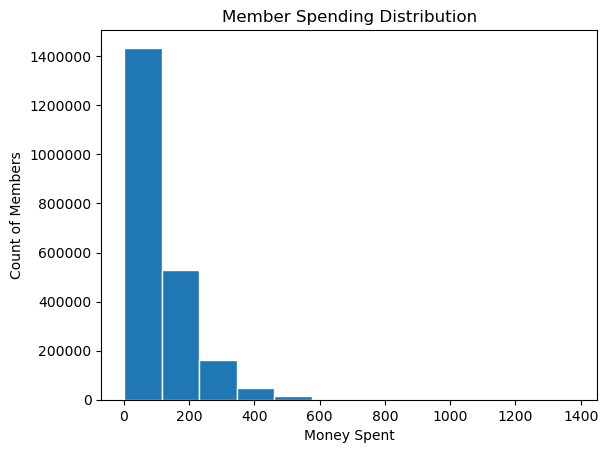

In [90]:
plt.ticklabel_format(style='plain', axis='y')

plt.hist(member_analysis.total_spent, bins=12,  edgecolor='white')
plt.xlabel('Money Spent')
plt.ylabel('Count of Members')
plt.title('Member Spending Distribution')


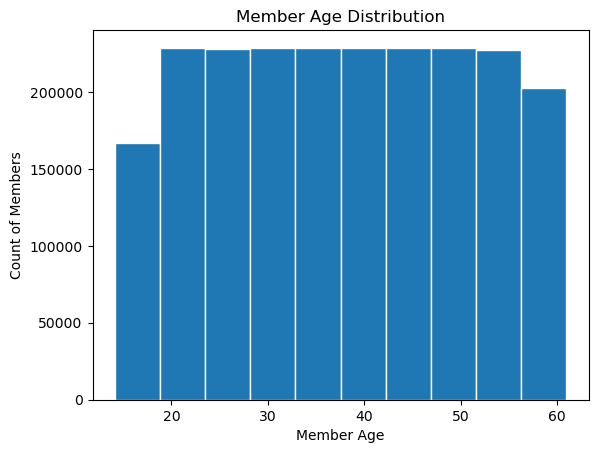

In [91]:
#plot user age
plt.hist(member_analysis.user_age, bins=10,  edgecolor='white')
plt.xlabel('Member Age')
plt.ylabel('Count of Members')
plt.title('Member Age Distribution');

(0.0, 18.0)

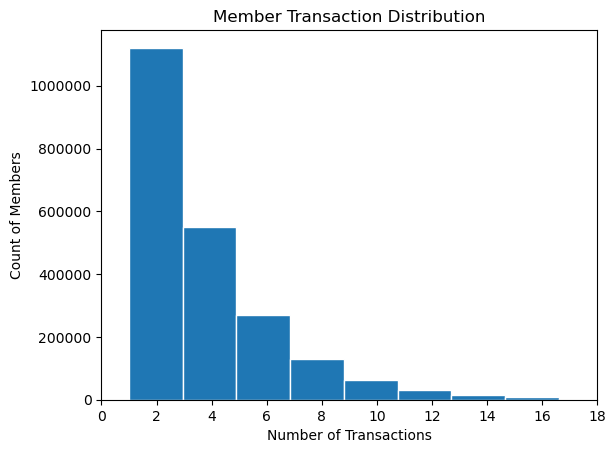

In [92]:
plt.ticklabel_format(style='plain', axis='y')

plt.hist(member_analysis.num_transactions, bins=20,  edgecolor='white' )
plt.xlabel('Number of Transactions')
plt.ylabel('Count of Members')
plt.title('Member Transaction Distribution')
plt.xlim(0, 18)


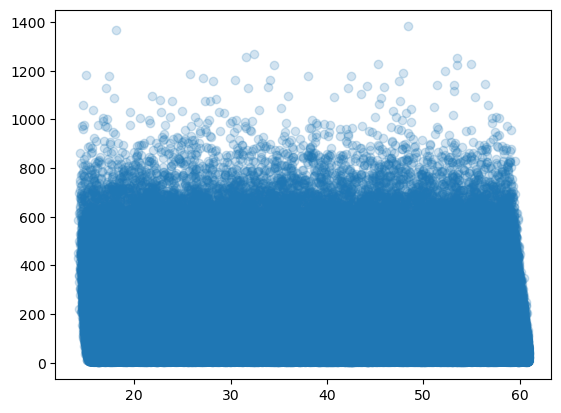

In [93]:
plt.scatter(member_analysis.user_age, member_analysis.total_spent, alpha = 0.2)

#### Finalizing Member Analysis dataset

* need to combine some fields from transactions, users and user's first transactions

In [94]:
#make age buckets to make a categorical variable

bins = [0,18,35, 60, 100]

labels = ['0-18','19-35', '36-60', '61+']

member_analysis['age_group'] = pd.cut(member_analysis['user_age'], bins = bins, labels = labels, right = True)

In [95]:
member_analysis.head()

,user_id,user_age,is_female,total_spent,num_transactions,returned_45days,age_group
0,491097,54.54,False,105.50,4,False,36-60
1,488642,52.62,True,96.00,3,False,36-60
2,488643,43.70,True,58.50,1,False,36-60
3,488644,47.78,False,119.00,3,False,36-60
4,488645,30.35,False,84.00,3,False,19-35


In [96]:
member_analysis.columns

Index(['user_id', 'user_age', 'is_female', 'total_spent', 'num_transactions',
       'returned_45days', 'age_group'],
      dtype='object')

In [97]:
member_analysis = member_analysis[['user_id', 'is_female', 'total_spent', 'num_transactions',
       'returned_45days', 'age_group']]

In [98]:
member_analysis.head()

,user_id,is_female,total_spent,num_transactions,returned_45days,age_group
0,491097,False,105.50,4,False,36-60
1,488642,True,96.00,3,False,36-60
2,488643,True,58.50,1,False,36-60
3,488644,False,119.00,3,False,36-60
4,488645,False,84.00,3,False,19-35


In [99]:
#member age_group distribution
member_analysis.groupby('age_group',observed=True).user_id.count()

age_group
0-18      126526
19-35     829855
36-60    1218828
61+        21048
Name: user_id, dtype: int64

In [100]:
#age group of those who returned within 45 days
member_analysis.groupby('age_group',observed=True).returned_45days.sum()

age_group
0-18      57198
19-35    355794
36-60    520308
61+        6272
Name: returned_45days, dtype: int64

In [101]:
#gender of those who returned within 45 days 
member_analysis.groupby('is_female',observed=True)['returned_45days'].sum()

is_female
False    470540
True     469032
Name: returned_45days, dtype: int64

In [102]:
member_analysis = member_analysis.merge(first_purchase_amount, on='user_id', how='inner')

In [103]:
member_analysis.head()

,user_id,is_female,total_spent,num_transactions,returned_45days,age_group,first_purchase_amount,store_id,payment_method_id,voucher_id
0,491097,False,105.50,4,False,36-60,37.00,2,3,NaN
1,488642,True,96.00,3,False,36-60,23.00,2,4,13.00
2,488643,True,58.50,1,False,36-60,58.50,4,2,13.00
3,488644,False,119.00,3,False,36-60,59.00,1,5,13.00
4,488645,False,84.00,3,False,19-35,21.00,7,1,NaN


In [104]:
member_analysis.sample(10)

,user_id,is_female,total_spent,num_transactions,returned_45days,age_group,first_purchase_amount,store_id,payment_method_id,voucher_id
2140372,777405,False,12.00,1,True,36-60,12.00,3,1,NaN
757024,1255700,True,40.00,1,True,36-60,40.00,3,2,NaN
1130154,1791693,False,54.50,2,False,19-35,6.00,9,3,NaN
308936,1512860,False,42.00,1,False,19-35,42.00,2,3,NaN
201476,424774,False,127.50,4,True,19-35,24.00,8,4,NaN
1980733,940538,True,63.00,1,True,19-35,63.00,9,5,NaN
905046,1928479,False,26.00,1,False,36-60,26.00,3,3,NaN
791793,1290469,False,75.50,2,True,19-35,66.00,8,2,NaN
223611,446909,True,143.00,5,True,19-35,8.00,2,4,NaN
79266,571516,False,60.50,2,True,19-35,25.50,4,5,NaN


#### Final cleaning steps for modeling

In [105]:
member_analysis.columns

Index(['user_id', 'is_female', 'total_spent', 'num_transactions',
       'returned_45days', 'age_group', 'first_purchase_amount', 'store_id',
       'payment_method_id', 'voucher_id'],
      dtype='object')

In [106]:
# need to change age group to dummies to keep them in these categories.
# I would like to see how age group affects retention so that targeted marketing can be recommended
dummies = pd.get_dummies(member_analysis.age_group, prefix = 'age_group')

In [107]:
dummies.head()

,age_group_0-18,age_group_19-35,age_group_36-60,age_group_61+
0,False,False,True,False
1,False,False,True,False
2,False,False,True,False
3,False,False,True,False
4,False,True,False,False


In [108]:
member_analysis = pd.concat([member_analysis,dummies], axis=1)

In [109]:
# need to make this binary for the logistic regression
member_analysis['used_voucher'] = member_analysis['voucher_id'].notna()

In [110]:
member_analysis.head()

,user_id,is_female,total_spent,num_transactions,returned_45days,age_group,first_purchase_amount,store_id,payment_method_id,voucher_id,age_group_0-18,age_group_19-35,age_group_36-60,age_group_61+,used_voucher
0,491097,False,105.50,4,False,36-60,37.00,2,3,NaN,False,False,True,False,False
1,488642,True,96.00,3,False,36-60,23.00,2,4,13.00,False,False,True,False,True
2,488643,True,58.50,1,False,36-60,58.50,4,2,13.00,False,False,True,False,True
3,488644,False,119.00,3,False,36-60,59.00,1,5,13.00,False,False,True,False,True
4,488645,False,84.00,3,False,19-35,21.00,7,1,NaN,False,True,False,False,False


In [111]:
member_analysis.columns

Index(['user_id', 'is_female', 'total_spent', 'num_transactions',
       'returned_45days', 'age_group', 'first_purchase_amount', 'store_id',
       'payment_method_id', 'voucher_id', 'age_group_0-18', 'age_group_19-35',
       'age_group_36-60', 'age_group_61+', 'used_voucher'],
      dtype='object')

## Predictive Modeling

### Feature Selection
Only using features available at time of first purchase - demographics and first purchase behavior. Excluded total_spent and num_transactions because those are outcomes we only know after the fact.


In [112]:
from sklearn.linear_model import LogisticRegression

In [113]:
#need to narrow down columns for this analysis because can't have the final state of a user's membership journey bias the results of the model. 
# only keeping demographic and behavioral patterns like using a voucher vs. considering the store/payment method because those are more operational. could be explored in the future. 
member_retention_analysis = member_analysis[['is_female', 'age_group_0-18', 'age_group_19-35', 'age_group_36-60', 'age_group_61+'
                 ,'first_purchase_amount', 'used_voucher', 'returned_45days']]

In [114]:
member_retention_analysis.head()

,is_female,age_group_0-18,age_group_19-35,age_group_36-60,age_group_61+,first_purchase_amount,used_voucher,returned_45days
0,False,False,False,True,False,37.00,False,False
1,True,False,False,True,False,23.00,True,False
2,True,False,False,True,False,58.50,True,False
3,False,False,False,True,False,59.00,True,False
4,False,False,True,False,False,21.00,False,False


In [118]:
logreg = LogisticRegression (penalty=None)

In [119]:
feature_names = ['is_female', 'age_group_0-18', 'age_group_19-35', 'age_group_36-60', 'age_group_61+'
                 ,'first_purchase_amount', 'used_voucher']
features = member_retention_analysis[feature_names].astype(int)

In [120]:
target = member_retention_analysis.returned_45days.astype(int)

In [124]:
# adding StandardScalar to normalize the model
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()


In [125]:
features_scaled = scaler.fit_transform(features)

In [127]:
target.isna().sum()

np.int64(0)

In [128]:
logreg.fit(features_scaled,target)

LogisticRegression(penalty=None)

In [129]:
logreg.predict(features_scaled)

array([0, 0, 0, ..., 0, 0, 0])

In [131]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

In [132]:
skf = StratifiedKFold(n_splits = 5, shuffle = True)

In [133]:
# cross_val_score(logreg, features_scaled, target, cv=skf)


array([0.57227514, 0.57220229, 0.57227417, 0.57206927, 0.57206017])

In [137]:
cross_val_score(logreg, features_scaled, target, cv=skf, scoring = 'roc_auc')

array([0.50863956, 0.51051917, 0.51153194, 0.51099556, 0.51047798])

### Lasso Logistic Regression
Using Lasso (L1 regularization) to identify most important features. Lasso shrinks unimportant coefficients to zero.

In [134]:
logreg_lasso = LogisticRegression(penalty='l1', solver='saga', max_iter=1000)
logreg_lasso.fit(features_scaled, target)

LogisticRegression(max_iter=1000, penalty='l1', solver='saga')

In [138]:
from sklearn.metrics import roc_auc_score

In [147]:
y_predict_proba = logreg_lasso.predict_proba(features_scaled)[:,1] # narrowing to only the probability of returning 
auc_score = roc_auc_score(target, y_predict_proba)

print(f"AUC Score: {auc_score:.3f}")

AUC Score: 0.511


In [136]:
#Lasso Logistic Regression shows which features the ones that make the most difference in a member coming back within 60 days 
pd.DataFrame({'feature': features.columns, 'coefficient': logreg_lasso.coef_[0]}).sort_values('coefficient', ascending=False)

,feature,coefficient
6,used_voucher,0.05
1,age_group_0-18,0.02
2,age_group_19-35,0.00
5,first_purchase_amount,-0.00
0,is_female,-0.00
3,age_group_36-60,-0.00
4,age_group_61+,-0.06


### Trying out Random Forest

In [148]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100)

# Cross-validation with AUC
rf_scores = cross_val_score(rf, features_scaled, target, cv=skf, scoring='roc_auc')
print(f"Random Forest AUC: {rf_scores.mean():.3f}")

Random Forest AUC: 0.509


In [1]:
# all three models show that demographics and first purchase behavior don't seem to be predict who will return within 45 days

### Retention Inflection Point Analysis

Trying to determine how many times a member needs to return before they might be considered long term.
* This has implications to consider how long the coffee shops would need to invest in marketing to members before they can rely on them and then turning their focus on growth instead. 

In [113]:
# get the max number of visits per user
max_visits = member_transactions_sorted.groupby('user_id')['visit_number'].max().reset_index()
max_visits.columns = ['user_id', 'total_visits']

In [115]:
max_visits.head()

,user_id,total_visits
0,1.00,34
1,2.00,40
2,3.00,33
3,4.00,25
4,5.00,40


In [116]:
max_visits['total_visits'].value_counts().sort_index()

total_visits
1     659353
2     461638
3     322796
4     226780
5     157827
6     110495
7      77048
8      53962
9      37745
10     26647
11     18686
12     13044
13      9062
14      6394
15      4409
16      3059
17      2215
18      1589
19      1040
20       764
21       521
22       348
23       233
24       209
25       126
26        90
27        52
28        37
29        34
30        17
31        13
32         4
33         3
34         5
35         2
36         2
37         5
38         1
40         2
Name: count, dtype: int64

In [117]:
len(max_visits)


2196257

In [118]:
max_visits['total_visits'] >= 2

0           True
1           True
2           True
3           True
4           True
           ...  
2196252    False
2196253    False
2196254    False
2196255    False
2196256    False
Name: total_visits, Length: 2196257, dtype: bool

In [119]:
# how many people have at least two viists
(max_visits['total_visits'] >= 2).sum()

np.int64(1536904)

In [122]:
# determining how many users at at least i visits up to 40 visits
for i in range(1, 40):
    count = (max_visits['total_visits'] >= i).sum()
    print(f"At least {i} visits: {count}")

At least 1 visits: 2196257
At least 2 visits: 1536904
At least 3 visits: 1075266
At least 4 visits: 752470
At least 5 visits: 525690
At least 6 visits: 367863
At least 7 visits: 257368
At least 8 visits: 180320
At least 9 visits: 126358
At least 10 visits: 88613
At least 11 visits: 61966
At least 12 visits: 43280
At least 13 visits: 30236
At least 14 visits: 21174
At least 15 visits: 14780
At least 16 visits: 10371
At least 17 visits: 7312
At least 18 visits: 5097
At least 19 visits: 3508
At least 20 visits: 2468
At least 21 visits: 1704
At least 22 visits: 1183
At least 23 visits: 835
At least 24 visits: 602
At least 25 visits: 393
At least 26 visits: 267
At least 27 visits: 177
At least 28 visits: 125
At least 29 visits: 88
At least 30 visits: 54
At least 31 visits: 37
At least 32 visits: 24
At least 33 visits: 20
At least 34 visits: 17
At least 35 visits: 12
At least 36 visits: 10
At least 37 visits: 8
At least 38 visits: 3
At least 39 visits: 2


In [125]:
# conversion rate 
for i in range(1, 40):
    current = (max_visits['total_visits'] >= i).sum()
    next_level = (max_visits['total_visits'] >= i + 1).sum()
    conversion_rate = next_level / current * 100
    print(f"Visit {i} to Visit {i+1}: {conversion_rate:.1f}%")

Visit 1 to Visit 2: 70.0%
Visit 2 to Visit 3: 70.0%
Visit 3 to Visit 4: 70.0%
Visit 4 to Visit 5: 69.9%
Visit 5 to Visit 6: 70.0%
Visit 6 to Visit 7: 70.0%
Visit 7 to Visit 8: 70.1%
Visit 8 to Visit 9: 70.1%
Visit 9 to Visit 10: 70.1%
Visit 10 to Visit 11: 69.9%
Visit 11 to Visit 12: 69.8%
Visit 12 to Visit 13: 69.9%
Visit 13 to Visit 14: 70.0%
Visit 14 to Visit 15: 69.8%
Visit 15 to Visit 16: 70.2%
Visit 16 to Visit 17: 70.5%
Visit 17 to Visit 18: 69.7%
Visit 18 to Visit 19: 68.8%
Visit 19 to Visit 20: 70.4%
Visit 20 to Visit 21: 69.0%
Visit 21 to Visit 22: 69.4%
Visit 22 to Visit 23: 70.6%
Visit 23 to Visit 24: 72.1%
Visit 24 to Visit 25: 65.3%
Visit 25 to Visit 26: 67.9%
Visit 26 to Visit 27: 66.3%
Visit 27 to Visit 28: 70.6%
Visit 28 to Visit 29: 70.4%
Visit 29 to Visit 30: 61.4%
Visit 30 to Visit 31: 68.5%
Visit 31 to Visit 32: 64.9%
Visit 32 to Visit 33: 83.3%
Visit 33 to Visit 34: 85.0%
Visit 34 to Visit 35: 70.6%
Visit 35 to Visit 36: 83.3%
Visit 36 to Visit 37: 80.0%
Visit 37 

* Seems that perhaps since this is synthetic data, that there is no specific inflection point and between the first and 23rd visit, the rate of members coming back for the next visit hovers around 70%. 

### Visualizations for Presentation 

In [133]:
age_retention = pd.DataFrame({
    'total': member_analysis.groupby('age_group', observed=True)['user_id'].count(),
    'returned_45days': member_analysis.groupby('age_group', observed=True)['returned_45days'].sum()
})

age_retention['return_rate'] = (age_retention['returned_45days'] / age_retention['total'] * 100).round(1)

age_retention

,total,returned_45days,return_rate
age_group,,,
0-18,126526,57198,45.20
19-35,829855,355794,42.90
36-60,1218828,520308,42.70
61+,21048,6272,29.80


(0.0, 60.0)

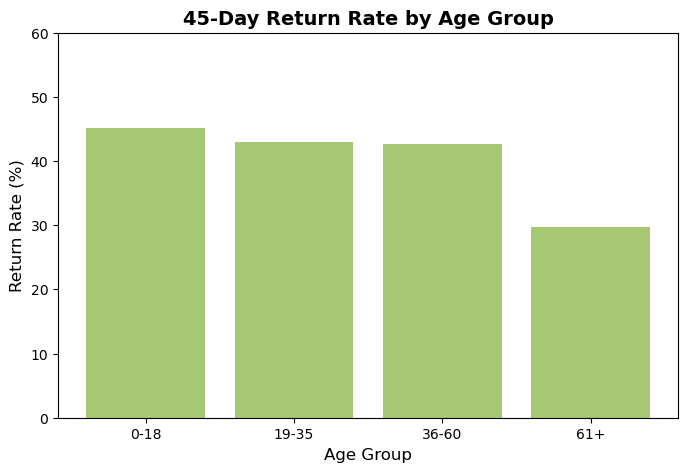

In [134]:
plt.figure(figsize=(8, 5))
plt.bar(age_retention.index, age_retention['return_rate'], color='#a6c875')
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Return Rate (%)', fontsize=12)
plt.title('45-Day Return Rate by Age Group', fontsize=14, fontweight='bold')
plt.ylim(0, 60)

# plt.savefig('age_group_retention')

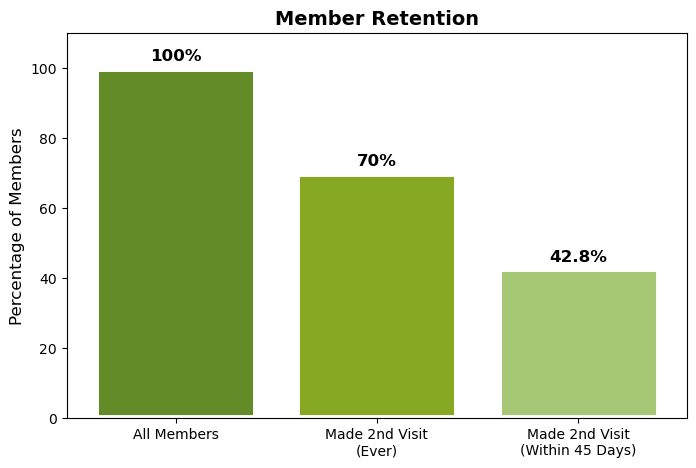

In [135]:
stages = ['All Members', 'Made 2nd Visit\n(Ever)', 'Made 2nd Visit\n(Within 45 Days)']
values = [100, 70, 42.8]
colors = ['#638b27','#87a922' , '#a6c875']

plt.figure(figsize=(8, 5))
bars = plt.bar(stages, values, color=colors, edgecolor='white', linewidth=5)
plt.ylabel('Percentage of Members', fontsize=12)
plt.title('Member Retention', fontsize=14, fontweight='bold')
plt.ylim(0, 110)

for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, f'{val}%', 
             ha='center', fontsize=12, fontweight='bold')
    
# plt.savefig('overall_member_retention')

(0.0, 18.0)

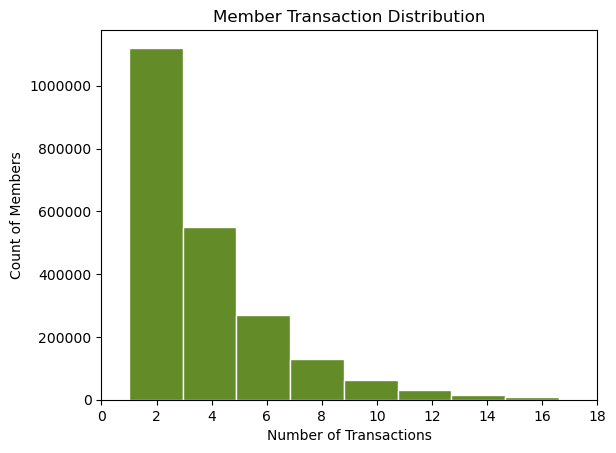

In [136]:
plt.ticklabel_format(style='plain', axis='y')

plt.hist(member_analysis.num_transactions, bins=20,  edgecolor='white', color = '#638b27' )
plt.xlabel('Number of Transactions')
plt.ylabel('Count of Members')
plt.title('Member Transaction Distribution')
plt.xlim(0, 18)

# plt.savefig('membership_transactions')

In [137]:
# %pip install dataframe-image

In [138]:
import seaborn as sns
import dataframe_image as dfi

In [139]:
coef_df = pd.DataFrame({
    'Feature': ['Used Voucher', 'Age 0-18', 'Age 19-35', 'Age 36-60', 'First Purchase $', 'Gender', 'Age 61+'],
    'Coefficient': [0.28, 0.19, 0.09, 0.08, 0.00, 0.00, -0.51],
    'Interpretation': ['↑ More likely', '↑ More likely', '↑ More likely', '↑ More likely', '— No effect', '— No effect', '↓ Less likely']
})

coef_df.style.background_gradient()

,Feature,Coefficient,Interpretation
0,Used Voucher,0.280000,↑ More likely
1,Age 0-18,0.190000,↑ More likely
2,Age 19-35,0.090000,↑ More likely
3,Age 36-60,0.080000,↑ More likely
4,First Purchase $,0.000000,— No effect
5,Gender,0.000000,— No effect
6,Age 61+,-0.510000,↓ Less likely


In [140]:
table =  coef_df

cm = sns.light_palette("darkgreen", as_cmap=True)
styled_table = table.style.background_gradient(cmap=cm)
styled_table

dfi.export(
    styled_table,
    "lasso_coefficients.png",
    table_conversion="matplotlib"
)


## Results and Conclusions

### Interpretation
With ~51% accuracy across multiple model types, demographics and first purchase behavior have limited power in predicting who will return within 45 days. 

Still, some patterns might be worth looking further into: 

- **Used Voucher (+0.28):** Strongest predictor of return
- **Age 61+ (-0.51):** Significantly less likely to return
- **Gender and First Purchase Amount:** No effect

There was no retention inflection point - the probability of a member making another visit stayed consistent at ~70% whether it was their 2nd visit or their 20th.

### Limitations
- This is synthetic data. Real customer behavior would likely show more variation (the flat ~70% retention rate at every visit level is too consistent)
- Model accuracy ~51% (barely better than random)
    - Even with running AUC and using a Random Forest classifier, results were similar.
- Correlation, not causation
- Only looked at first purchase behavior

### Recommendations
1. Continue pushing vouchers to new members
2. Target 61+ age group with promotions
3. Focus marketing on younger demographics